# TOPIK Test Result Analysis

Analyzes test results from `analysis/test-results/` using original question data from `src/data/reading/`.

**Covers:** topik-35, topik-41, topik-91

In [7]:
import json
import os
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
from pathlib import Path

# ── Korean font (macOS) ────────────────────────────────────────────────────────
matplotlib.rcParams['font.family'] = ['AppleGothic', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# ── Paths ──────────────────────────────────────────────────────────────────────
REPO_ROOT = Path(os.getcwd()).parent.parent  # analysis/reports → repo root
RESULTS_DIR = REPO_ROOT / 'analysis' / 'test-results'
READING_DIR = REPO_ROOT / 'src' / 'data' / 'reading'

print(f'Repo root: {REPO_ROOT}')
print(f'Test results: {RESULTS_DIR}')
print(f'Reading data: {READING_DIR}')

Repo root: /Users/dopark/Desktop/projects/topik-vocab
Test results: /Users/dopark/Desktop/projects/topik-vocab/analysis/test-results
Reading data: /Users/dopark/Desktop/projects/topik-vocab/src/data/reading


## 1. Load Data

In [8]:
def load_questions(topik_number: str) -> dict:
    """Load all question JSONs for a given TOPIK number into a dict keyed by 문제_번호."""
    questions = {}
    reading_path = READING_DIR / topik_number
    for json_file in sorted(reading_path.glob('*.json')):
        with open(json_file, encoding='utf-8') as f:
            data = json.load(f)
        if isinstance(data, list):
            for q in data:
                questions[str(q['문제_번호'])] = q
    return questions


def load_answers(topik_key: str) -> dict:
    """Load answers.json for a given topik key (e.g. 'topik-41')."""
    path = RESULTS_DIR / topik_key / 'answers.json'
    with open(path, encoding='utf-8') as f:
        return json.load(f)


def compose_records(topik_number: str, topik_key: str) -> list:
    """Join question data with answer data into a unified list of records."""
    questions = load_questions(topik_number)
    answers = load_answers(topik_key)
    records = []
    for q_num_str, ans in answers.items():
        q = questions.get(q_num_str, {})
        records.append({
            '시험': topik_key,
            '문제_번호': int(q_num_str),
            '지시문': q.get('지시문', ''),
            '배점': q.get('배점', ''),
            '문제_내용': q.get('문제_내용', ''),
            '선택지': q.get('선택지', {}),
            '선택한_정답': ans.get('selected'),
            '정답': q.get('정답'),
            '주제': q.get('주제', ''),
            '걸린시간': ans.get('timeSpentMs', 0),
            '정답유무': ans.get('correct', False),
        })
    return records


# ── Load all three tests ───────────────────────────────────────────────────────
TEST_MAP = [
    ('35', 'topik-35'),
    ('41', 'topik-41'),
    ('91', 'topik-91'),
]

all_records = []
for topik_num, topik_key in TEST_MAP:
    records = compose_records(topik_num, topik_key)
    all_records.extend(records)
    print(f'{topik_key}: {len(records)} questions loaded')

df = pd.DataFrame(all_records)
wrong_df = df[df['정답유무'] == False].copy()

print(f'\nTotal questions: {len(df)}')
print(f'Wrong answers:   {len(wrong_df)}')
print(f'Correct answers: {len(df) - len(wrong_df)}')

topik-35: 50 questions loaded
topik-41: 50 questions loaded
topik-91: 50 questions loaded

Total questions: 150
Wrong answers:   28
Correct answers: 122


## 2. Wrong Answers Structured Data

The `wrong_answers` list matches the requested format.

In [9]:
def ms_to_mmss(ms):
    m = int(ms) // 60000
    s = (int(ms) % 60000) // 1000
    return f'{m:02d}:{s:02d}'


wrong_answers = wrong_df.to_dict(orient='records')

print(f'wrong_answers ({len(wrong_answers)} items):')
for w in wrong_answers:
    print(f"  [{w['시험']}] Q{w['문제_번호']:>2}  주제: {w['주제']:<6}  "
          f"선택: {w['선택한_정답']} / 정답: {w['정답']}  "
          f"시간: {ms_to_mmss(w['걸린시간'])}")

wrong_answers (28 items):
  [topik-35] Q 7  주제: 과학      선택: 2 / 정답: 1.0  시간: 00:31
  [topik-35] Q16  주제: 사회      선택: 1 / 정답: 2.0  시간: 03:16
  [topik-35] Q18  주제: 과학      선택: 4 / 정답: 3.0  시간: 02:36
  [topik-35] Q23  주제: 인물      선택: 4 / 정답: 1.0  시간: 03:46
  [topik-35] Q32  주제: 과학      선택: 3 / 정답: 2.0  시간: 03:37
  [topik-35] Q42  주제: 사회      선택: 3 / 정답: nan  시간: 03:14
  [topik-35] Q43  주제: 사회      선택: 2 / 정답: nan  시간: 01:48
  [topik-35] Q44  주제: 경제      선택: 4 / 정답: 2.0  시간: 10:16
  [topik-35] Q46  주제: 경제      선택: 3 / 정답: 2.0  시간: 05:55
  [topik-35] Q47  주제: 경제      선택: 4 / 정답: 3.0  시간: 02:24
  [topik-41] Q15  주제: 사회      선택: 1 / 정답: 3.0  시간: 04:15
  [topik-41] Q16  주제: 사회      선택: 2 / 정답: 4.0  시간: 02:42
  [topik-41] Q17  주제: 사회      선택: 3 / 정답: 4.0  시간: 03:58
  [topik-41] Q23  주제: 사회      선택: 2 / 정답: 1.0  시간: 02:28
  [topik-41] Q32  주제: 문화      선택: 1 / 정답: 4.0  시간: 03:34
  [topik-41] Q41  주제: 과학      선택: 2 / 정답: 3.0  시간: 04:34
  [topik-41] Q43  주제: 문화      선택: 1 / 정답: 3.0  시간: 00:14
  [to

## 3. Histogram — Wrong Answers by 문제번호

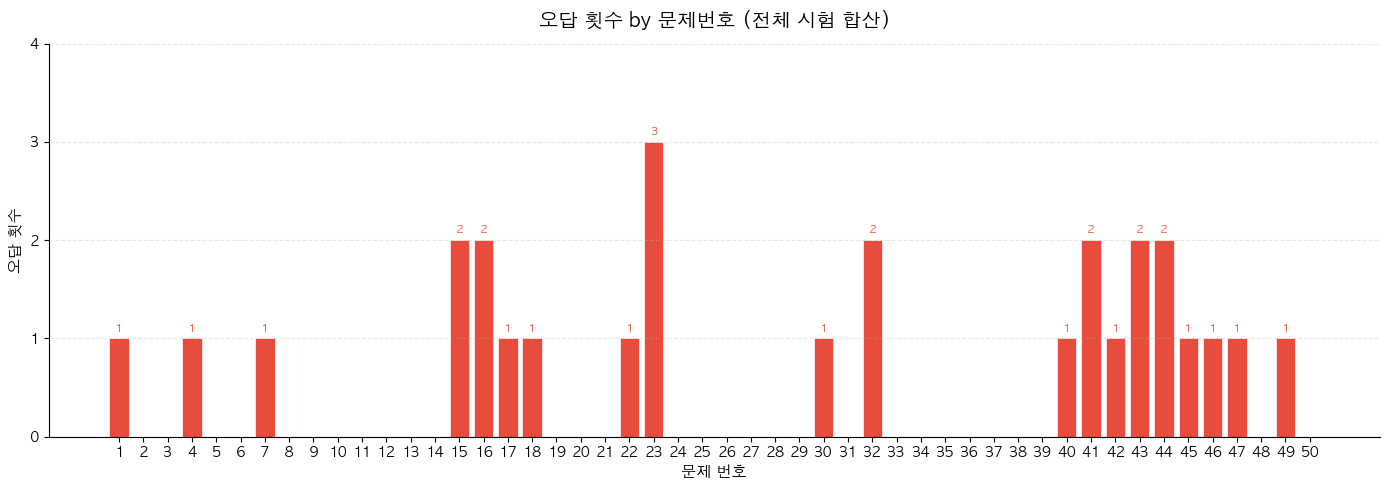

Saved: wrong_answers_by_question.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

# Count wrong answers per question number across all tests
wrong_counts = wrong_df.groupby('문제_번호').size().reset_index(name='오답_횟수')

# Ensure all 1-50 are represented
all_q_nums = pd.DataFrame({'문제_번호': range(1, 51)})
wrong_counts = all_q_nums.merge(wrong_counts, on='문제_번호', how='left').fillna(0)
wrong_counts['오답_횟수'] = wrong_counts['오답_횟수'].astype(int)

colors = ['#e74c3c' if c > 0 else '#bdc3c7' for c in wrong_counts['오답_횟수']]
bars = ax.bar(wrong_counts['문제_번호'], wrong_counts['오답_횟수'],
              color=colors, edgecolor='white', linewidth=0.5)

# Annotate non-zero bars
for bar, count in zip(bars, wrong_counts['오답_횟수']):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                str(count), ha='center', va='bottom', fontsize=8,
                fontweight='bold', color='#e74c3c')

ax.set_title('오답 횟수 by 문제번호 (전체 시험 합산)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('문제 번호', fontsize=11)
ax.set_ylabel('오답 횟수', fontsize=11)
ax.set_xticks(range(1, 51))
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_ylim(0, wrong_counts['오답_횟수'].max() + 1)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('wrong_answers_by_question.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: wrong_answers_by_question.png')

## 4. Histogram — All Answers by Time Spent

최솟값: 00:04  → [topik-91] Q6 (사회)
최댓값: 10:16  → [topik-35] Q44 (경제)


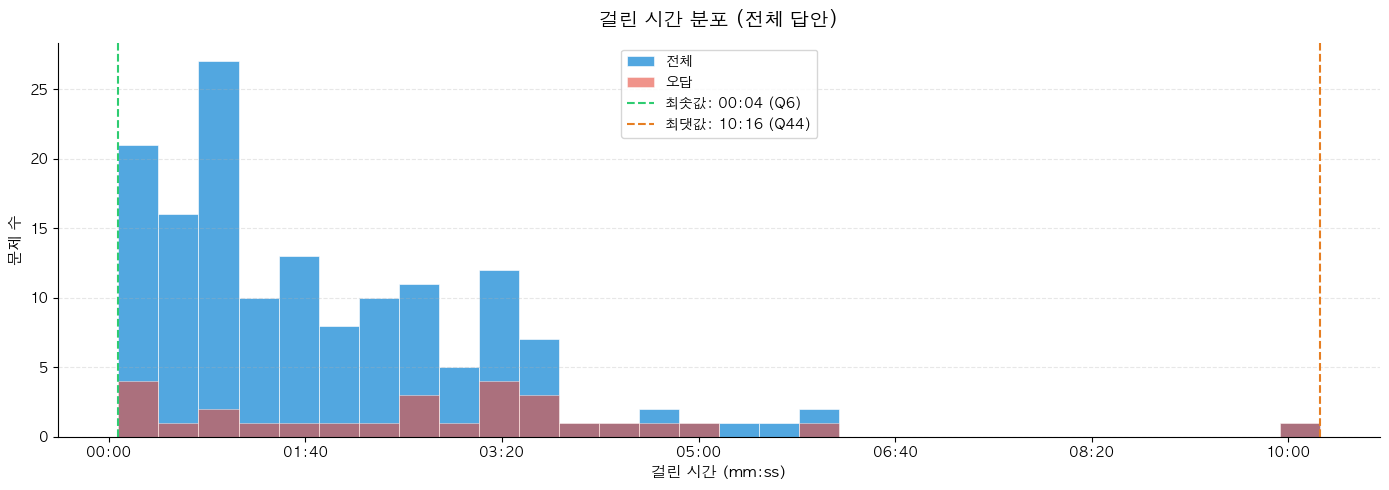

Saved: time_distribution.png


In [11]:
min_ms = df['걸린시간'].min()
max_ms = df['걸린시간'].max()
min_q = df.loc[df['걸린시간'].idxmin()]
max_q = df.loc[df['걸린시간'].idxmax()]

print(f"최솟값: {ms_to_mmss(min_ms)}  → [{min_q['시험']}] Q{min_q['문제_번호']} ({min_q['주제']})")
print(f"최댓값: {ms_to_mmss(max_ms)}  → [{max_q['시험']}] Q{max_q['문제_번호']} ({max_q['주제']})")

fig, ax = plt.subplots(figsize=(14, 5))

# Convert ms → seconds for x-axis readability
time_sec = df['걸린시간'] / 1000
n, bins, _ = ax.hist(time_sec, bins=30, color='#3498db', edgecolor='white',
                      linewidth=0.5, alpha=0.85, label='전체')

# Overlay wrong answers in red
ax.hist(wrong_df['걸린시간'] / 1000, bins=bins, color='#e74c3c',
        edgecolor='white', linewidth=0.5, alpha=0.6, label='오답')

# Min / max markers
ax.axvline(min_ms / 1000, color='#2ecc71', linestyle='--', linewidth=1.5,
           label=f"최솟값: {ms_to_mmss(min_ms)} (Q{int(min_q['문제_번호'])})")
ax.axvline(max_ms / 1000, color='#e67e22', linestyle='--', linewidth=1.5,
           label=f"최댓값: {ms_to_mmss(max_ms)} (Q{int(max_q['문제_번호'])})")

ax.set_title('걸린 시간 분포 (전체 답안)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('걸린 시간 (mm:ss)', fontsize=11)
ax.set_ylabel('문제 수', fontsize=11)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x)//60:02d}:{int(x)%60:02d}'))
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: time_distribution.png')

## 5. Questions That Took More Than 240 Seconds

In [12]:
THRESHOLD_MS = 240 * 1000  # 4 minutes

slow_df = df[df['걸린시간'] > THRESHOLD_MS].copy()
slow_df = slow_df.sort_values('걸린시간', ascending=False)
slow_df['걸린시간(mm:ss)'] = slow_df['걸린시간'].apply(ms_to_mmss)

display_cols = ['시험', '문제_번호', '주제', '걸린시간(mm:ss)', '정답유무', '지시문']

print(f'Questions taking > 4:00 (240s): {len(slow_df)}\n')

if len(slow_df) == 0:
    print('해당 없음 (모든 문제가 240초 이내)')
else:
    pd.set_option('display.max_colwidth', 55)
    pd.set_option('display.width', 150)
    print(slow_df[display_cols].to_string(index=False))

    print('\n주제별 분포:')
    print(slow_df['주제'].value_counts().to_string())

Questions taking > 4:00 (240s): 9

      시험  문제_번호 주제 걸린시간(mm:ss)  정답유무                                                           지시문
topik-35     44 경제       10:16 False        [44~45] 다음을 읽고 물음에 답하십시오. / 44. 이 글의 주제로 알맞은 것을 고르십시오.
topik-35     46 경제       05:55 False [46~47] 다음을 읽고 물음에 답하십시오. / 46. 다음 문장이 들어가기에 가장 알맞은 곳을 고르십시오.
topik-35     48 사회       05:52  True         [48~50] 다음을 읽고 물음에 답하십시오. / 48. 필자가 이 글을 쓴 목적을 고르십시오.
topik-35     41 역사       05:40  True               [39~41] 다음 글에서 <보기>의 문장이 들어가기에 가장 알맞은 곳을 고르십시오.
topik-35     37 사회       05:14  True                            [35~38] 다음 글의 주제로 가장 알맞은 것을 고르십시오.
topik-91     15 과학       04:52 False                                      다음을 순서에 맞게 배열한 것을 고르십시오.
topik-35     17 문화       04:40  True                 [16~18] 다음을 읽고 ( )에 들어갈 내용으로 가장 알맞은 것을 고르십시오.
topik-41     41 과학       04:34 False               [39~41] 다음 글에서 <보기>의 문장이 들어가기에 가장 알맞은 곳을 고르십시오.
topik-41     15 사회       04:15 False                             [13~15] 다